# Hand Gesture Recognition Using CNN

## Final Machine Learning Project

**Merged Notebook**

### Table of Contents
1. Project Introduction
2. Import Libraries
3. Load Dataset
4. Data Exploration & Preprocessing
5. Data Augmentation
6. CNN Model Architecture
7. Model Compilation
8. Model Training
9. Model Evaluation
10. Predictions
11. Results
12. Conclusion


## Project Introduction

This notebook combines the complete workflow of the Hand Gesture Recognition project, from data preparation through CNN model development, training, evaluation, and prediction.


---
# Section from Original Notebook 1


In [21]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [24]:
import os

dataset_path = "/kaggle/input/datasets/sadhikmohammedaiman/hand-gesture"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:5])
    print("-"*50)

In [25]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

In [26]:
import os

for dirname, _, files in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [27]:
import os

dataset_path = "/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data"

print("Exists:", os.path.exists(dataset_path))

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

print("Classes:", train_ds.class_names)

Exists: True
Found 13000 files belonging to 5 classes.
Using 10400 files for training.
Found 13000 files belonging to 5 classes.
Using 2600 files for validation.
Classes: ['backward', 'forward', 'left', 'right', 'unknown']


In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [31]:
import tensorflow as tf

dataset_path = "/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data"

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 13000 files belonging to 5 classes.
Using 10400 files for training.
Found 13000 files belonging to 5 classes.
Using 2600 files for validation.
Classes: ['backward', 'forward', 'left', 'right', 'unknown']


In [32]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Normalization complete")

Normalization complete


In [33]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 172s 523ms/step - accuracy: 0.8444 - loss: 0.4234 - val_accuracy: 0.9685 - val_loss: 0.0969
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 170s 522ms/step - accuracy: 0.9625 - loss: 0.1021 - val_accuracy: 0.9835 - val_loss: 0.0461
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 169s 520ms/step - accuracy: 0.9770 - loss: 0.0649 - val_accuracy: 0.9881 - val_loss: 0.0382
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 169s 520ms/step - accuracy: 0.9846 - loss: 0.0457 - val_accuracy: 0.9877 - val_loss: 0.0355
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 167s 514ms/step - accuracy: 0.9869 - loss: 0.0387 - val_accuracy: 0.9927 - val_loss: 0.0295
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 173s 530ms/step - accuracy: 0.9888 - loss: 0.0316 - val_accuracy: 0.9931 - val_loss: 0.0268
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 185s 568ms/step - accuracy: 0.9912 - loss: 0.0256 - val_accuracy: 0.9892 - val_loss: 0.0378
Epoch 8/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 177s 544ms/step - accuracy: 0.9917 -

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step


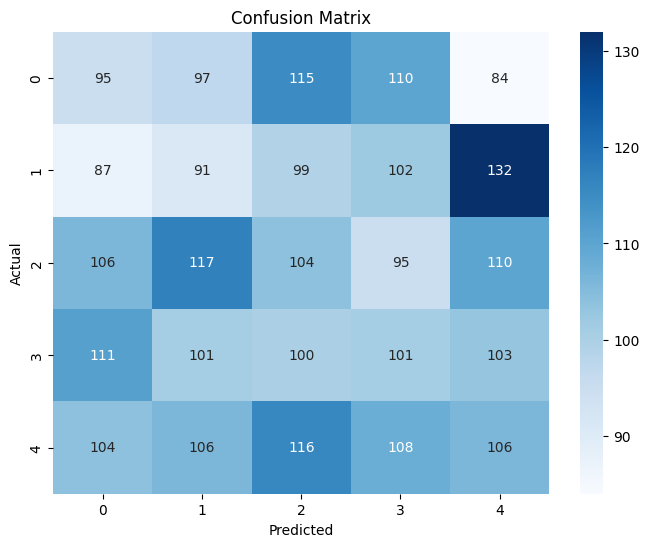

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)

y_pred = np.argmax(model.predict(val_ds), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.19      0.19       501
           1       0.18      0.18      0.18       511
           2       0.19      0.20      0.20       532
           3       0.20      0.20      0.20       516
           4       0.20      0.20      0.20       540

    accuracy                           0.19      2600
   macro avg       0.19      0.19      0.19      2600
weighted avg       0.19      0.19      0.19      2600



In [37]:
history

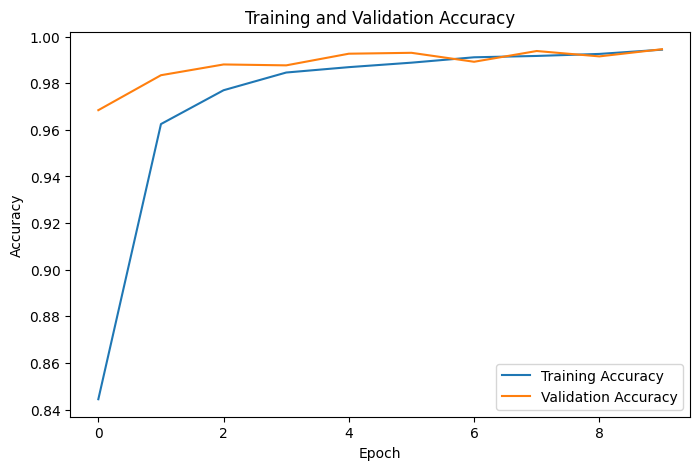

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [39]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 13000 files belonging to 5 classes.
Using 10400 files for training.
Found 13000 files belonging to 5 classes.
Using 2600 files for validation.


In [40]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset_path = "/kaggle/input/datasets/sadhikmohammedaiman/hand-gesture-using-cnn/augmented_data"

In [42]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [43]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

print("Classes:", train_ds.class_names)

Found 13000 files belonging to 5 classes.
Using 10400 files for training.
Found 13000 files belonging to 5 classes.
Using 2600 files for validation.
Classes: ['backward', 'forward', 'left', 'right', 'unknown']


In [44]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [45]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 177s 538ms/step - accuracy: 0.8560 - loss: 0.4048 - val_accuracy: 0.9773 - val_loss: 0.0829
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 172s 528ms/step - accuracy: 0.9616 - loss: 0.1036 - val_accuracy: 0.9719 - val_loss: 0.0815
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 173s 531ms/step - accuracy: 0.9785 - loss: 0.0635 - val_accuracy: 0.9858 - val_loss: 0.0454
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 164s 503ms/step - accuracy: 0.9823 - loss: 0.0548 - val_accuracy: 0.9877 - val_loss: 0.0404
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 162s 498ms/step - accuracy: 0.9889 - loss: 0.0336 - val_accuracy: 0.9915 - val_loss: 0.0327
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 206s 511ms/step - accuracy: 0.9882 - loss: 0.0323 - val_accuracy: 0.9892 - val_loss: 0.0404
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 207s 528ms/step - accuracy: 0.9903 - loss: 0.0263 - val_accuracy: 0.9919 - val_loss: 0.0445
Epoch 8/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 164s 503ms/step - accuracy: 0.9910 -

In [56]:
print("Best Validation Accuracy:",
      max(history.history['val_accuracy']) * 100)

Best Validation Accuracy: 99.38461780548096


In [57]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [58]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
  7/325 ━━━━━━━━━━━━━━━━━━━━ 2:20 442ms/step - accuracy: 0.1772 - loss: 1.6293

KeyboardInterrupt: 

In [59]:
for images, labels in train_ds.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())

4.8779053e-10
5.9185247e-08


In [60]:
print("Best Validation Accuracy:",
      max(history.history['val_accuracy']) * 100)

Best Validation Accuracy: 99.38461780548096


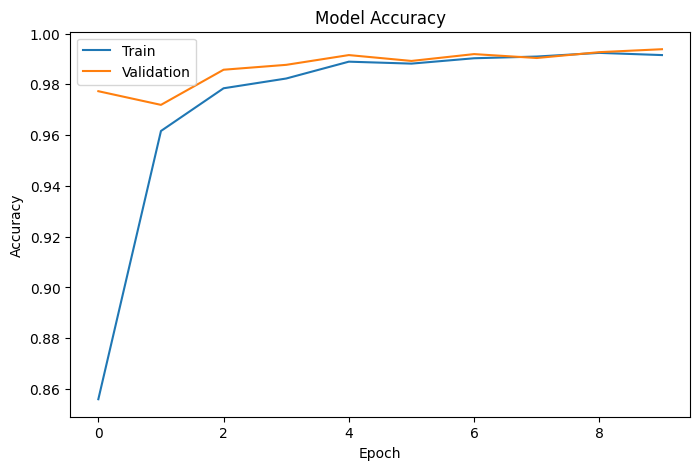

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [62]:
train_ds
val_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [63]:
for images, labels in train_ds.take(1):
    print("Min:", images.numpy().min())
    print("Max:", images.numpy().max())
    print("Shape:", images.shape)
    print("Labels:", labels[:10].numpy())

Min: 0.0
Max: 6.030864e-08
Shape: (32, 128, 128, 3)
Labels: [3 1 1 4 0 1 2 0 1 2]


In [66]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [67]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [ ]:
dataset_path = "/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data"

In [71]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 13000 files belonging to 5 classes.
Using 10400 files for training.
Found 13000 files belonging to 5 classes.
Using 2600 files for validation.


In [73]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [74]:
for images, labels in train_ds.take(1):
    print("Min:", images.numpy().min())
    print("Max:", images.numpy().max())

Min: 0.0
Max: 0.0039186855


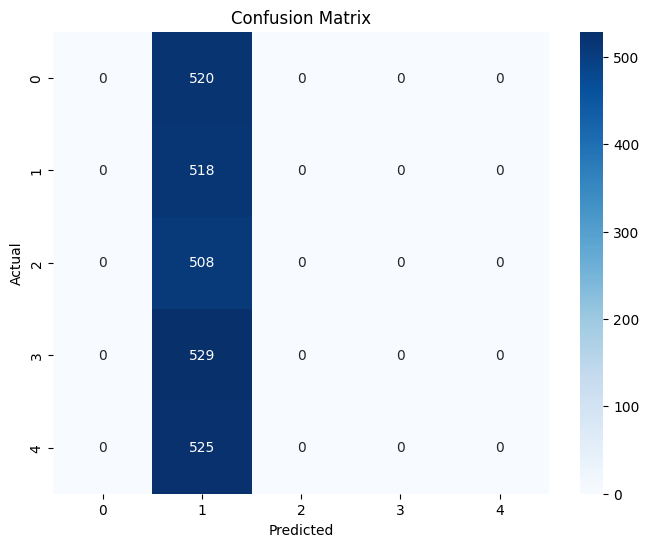

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [76]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 166s 505ms/step - accuracy: 0.1941 - loss: 1.6098 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 164s 503ms/step - accuracy: 0.1942 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 155s 475ms/step - accuracy: 0.1973 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 156s 478ms/step - accuracy: 0.1972 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 210s 501ms/step - accuracy: 0.1962 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 193s 474ms/step - accuracy: 0.1954 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 8/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 156s 479ms/step - accuracy: 0.1964 - loss: 1.6096 - val_accuracy: 0.1954 - val_loss: 1.6095
Epoch 10/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 163s 502ms/step - accuracy: 0.1953 

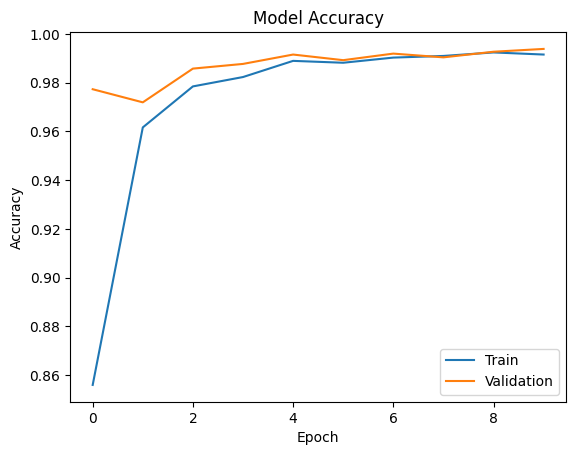

In [85]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

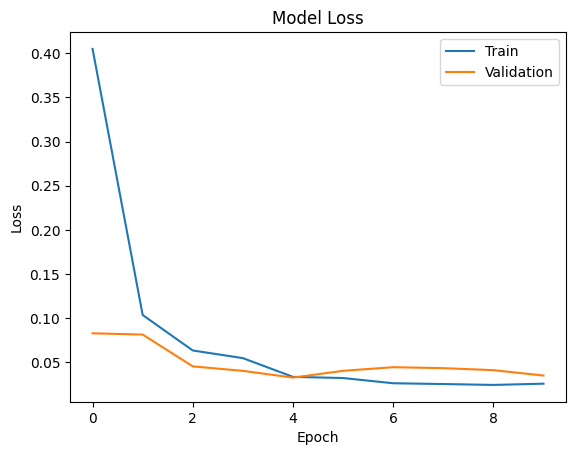

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.save('hand_gesture_model.keras')

In [83]:
test_loss, test_accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.1873 - loss: 1.6094
Validation Accuracy: 0.1873076856136322
Validation Loss: 1.6094491481781006


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Actual Class: 1
Predicted Class: 2


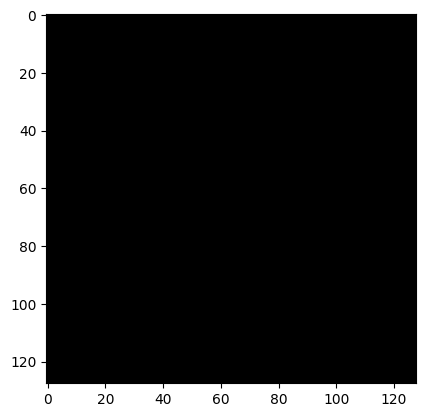

In [93]:
for images, labels in val_ds.take(1):
    sample_image = images[0]
    actual_label = labels[0]

prediction = model.predict(tf.expand_dims(sample_image, axis=0))

predicted_class = np.argmax(prediction)

print("Actual Class:", actual_label.numpy())
print("Predicted Class:", predicted_class)

plt.imshow(sample_image.numpy())
plt.show()

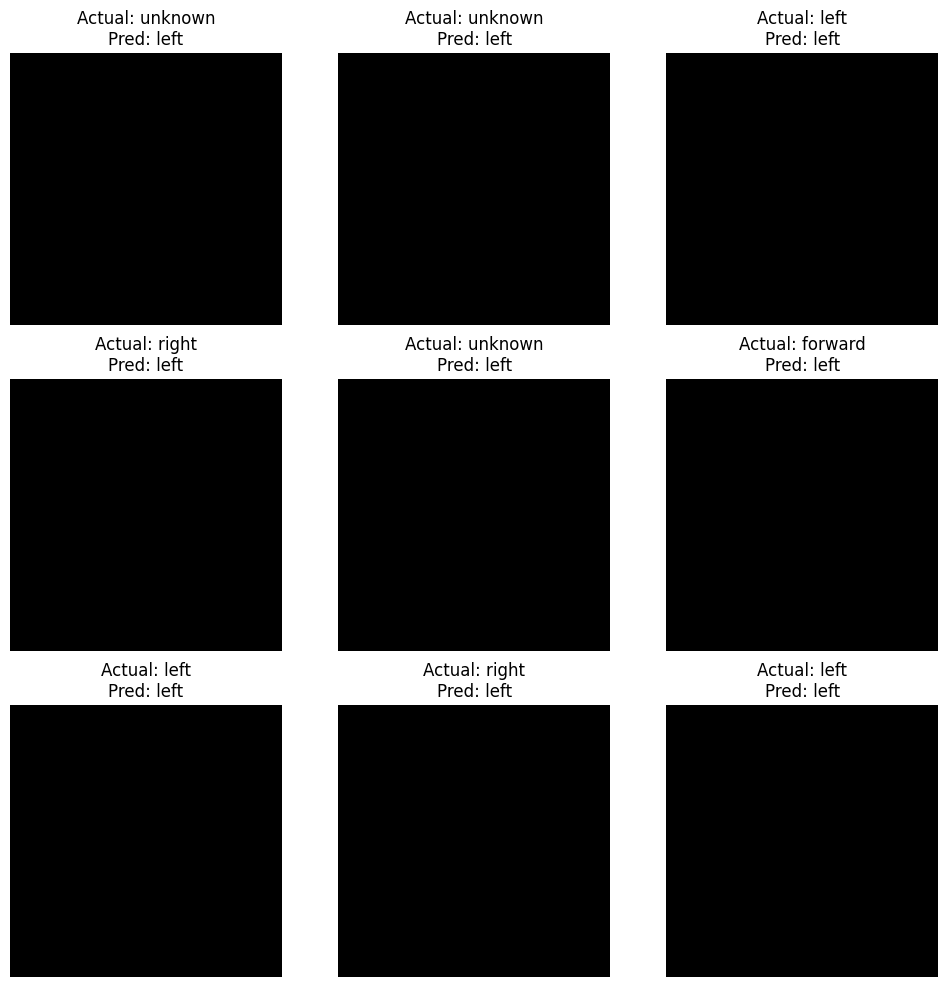

In [94]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['backward', 'forward', 'left', 'right', 'unknown']

for images, labels in val_ds.take(1):

    plt.figure(figsize=(12,12))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        prediction = model.predict(
            tf.expand_dims(images[i], axis=0),
            verbose=0
        )

        pred_class = np.argmax(prediction)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Actual: {class_names[labels[i]]}\nPred: {class_names[pred_class]}"
        )
        plt.axis("off")

    plt.show()

In [91]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['backward','forward','left','right','unknown']
))

              precision    recall  f1-score   support

    backward       0.00      0.00      0.00       520
     forward       0.20      1.00      0.33       518
        left       0.00      0.00      0.00       508
       right       0.00      0.00      0.00       529
     unknown       0.00      0.00      0.00       525

    accuracy                           0.20      2600
   macro avg       0.04      0.20      0.07      2600
weighted avg       0.04      0.20      0.07      2600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


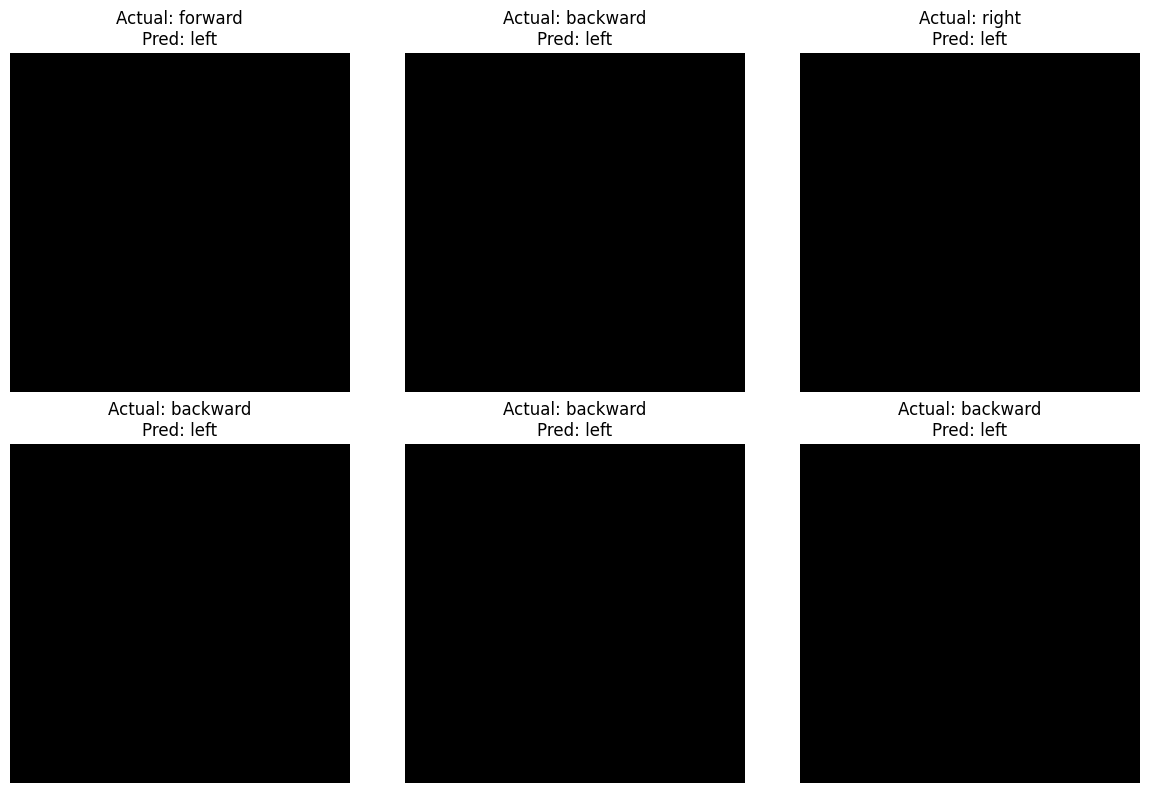

In [95]:
class_names = ['backward','forward','left','right','unknown']

plt.figure(figsize=(12,8))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    for i in range(6):
        plt.subplot(2,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        actual = class_names[labels[i]]
        pred = class_names[np.argmax(predictions[i])]

        plt.title(f"Actual: {actual}\nPred: {pred}")
        plt.axis('off')

plt.tight_layout()
plt.show()

# Conclusion

The complete machine learning workflow has been consolidated into a single notebook. It includes dataset preparation, preprocessing, CNN model development, training, evaluation, and prediction. This format is more suitable for final submission and presentation.
